## 0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn

# Check PyTorch version
print(torch.__version__)

# Ensure CUDA is available and use both GPUs
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

if device == 'cuda':
    # Display the number of GPUs
    print(f"Number of GPUs available: {torch.cuda.device_count()}")

    # Initialize both GPUs by performing dummy operations
    dummy_tensor0 = torch.randn(10, 10).to('cuda:0')
    dummy_tensor1 = torch.randn(10, 10).to('cuda:1')

    # Ensure tensors are moved to respective GPUs
    dummy_tensor0 = dummy_tensor0.to('cuda:0')
    dummy_tensor1 = dummy_tensor1.to('cuda:1')

    # Check GPU memory usage
    !nvidia-smi

# Define a simple dummy model to trigger GPU utilization
class DummyModel(nn.Module):
    def __init__(self):
        super(DummyModel, self).__init__()
        self.fc = nn.Linear(10, 10)
    
    def forward(self, x):
        return self.fc(x)

# Initialize the dummy model
model = DummyModel()

# Wrap the model with DataParallel to use multiple GPUs
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model, device_ids=[0, 1])

# Move the model to GPU(s)
model.to(device)

# Display the dummy model summary to ensure it is using GPUs
print(model)

# Dummy operation to utilize the model and ensure both GPUs are active
dummy_input = torch.randn(10, 10).to(device)
dummy_output = model(dummy_input)
print(dummy_output)

2.1.2
Device: cuda
Number of GPUs available: 2
Thu May 23 06:56:59 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   52C    P0              29W /  70W |    105MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+--------------------

## 1.dataset creation

In [2]:
#import os
#import shutil

# Define paths to your datasets
#dataset4_path = '/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train'
#dataset3_path = '/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train'
#dataset2_path = '/kaggle/input/american-sign-language/ASL_Dataset/Train'
#dataset1_path = '/kaggle/input/american-sign-language-09az/American'

# Define path to the new merged dataset
#merged_dataset_path = 'asl_merged_dataset'

# List of all datasets paths
#datasets = [dataset1_path, dataset2_path, dataset3_path, dataset4_path]

# Ensure the merged dataset directory exists
#if not os.path.exists(merged_dataset_path):
   # os.makedirs(merged_dataset_path)

# Function to check if a string contains any digit
#def contains_digit(s):
 #   return any(char.isdigit() for char in s)

# Function to merge datasets
#def merge_datasets(datasets, merged_dataset_path):
   # for dataset in datasets:
        #for subdir in os.listdir(dataset):
           # subdir_path = os.path.join(dataset, subdir)
           # if os.path.isdir(subdir_path):
                # Skip subdirectories with names containing digits
               # if contains_digit(subdir):
                 #   continue

                # Convert subdir name to lowercase
              #  lower_subdir = subdir.lower()
                
                # Ensure subdirectory exists in the merged dataset
               # merged_subdir_path = os.path.join(merged_dataset_path, lower_subdir)
               # if not os.path.exists(merged_subdir_path):
                #    os.makedirs(merged_subdir_path)
                
                # Copy all files from the current subdir to the corresponding subdir in the merged dataset
               # for file_name in os.listdir(subdir_path):
                  #  file_path = os.path.join(subdir_path, file_name)
                   # if os.path.isfile(file_path):
                      #  shutil.copy(file_path, merged_subdir_path)

# Merge the datasets
#merge_datasets(datasets, merged_dataset_path)

#print(f'Merged dataset created at: {merged_dataset_path}')

## 2. Data Visualization

In [ ]:
from pathlib import Path
import os
import random
from PIL import Image

# random.seed(42)
image_path = Path("/kaggle/input/asl-merged-img/asl_merged_dataset")
image_path_list = list(image_path.glob("*/*.jpg"))
# print(len(image_path_list))
random_image_path = random.choice(image_path_list)
# print(random_image_path)
# the image class is the name of the directory where iamges resides
image_class = random_image_path.parent.stem
# print(image_class)

img = Image.open(random_image_path)

# Print metadata
print(f'Random image path: {random_image_path}')
print(f'Image Class: {image_class}')
print(f'Image Height: {img.height}')
print(f'Image Width: {img.width}')


In [ ]:
# Visualizing using matplotliib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
fig = plt.figure(figsize=(6, 5))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]", fontsize = 10)
plt.axis(False)
plt.show()

In [ ]:
img_as_array

## 3. Transforming data

In [ ]:
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

print(torchvision.__version__)

# Transform image
data_transform = transforms.Compose([
    transforms.Resize(size = (128, 128)),         # Resize our images to 128X128
    transforms.ToTensor()
])


transformed_data = data_transform(img)
transformed_data, transformed_data.shape, transformed_data.dtype

## 4. Loading data with ImageFolder and Split into Train and Test Data

In [7]:
# Setup source directory
source_dir = '/kaggle/input/asl-merged-img/asl_merged_dataset'

source_data = datasets.ImageFolder(root = source_dir,
                                  transform = data_transform, # Transforms input data into tensors
                                  target_transform = None)    # Transform labels into none

source_data

Dataset ImageFolder
    Number of datapoints: 366967
    Root location: /kaggle/input/asl-merged-img/asl_merged_dataset
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=warn)
               ToTensor()
           )

In [8]:
from torch.utils.data import random_split

train_size = int(0.8 * len(source_data))
test_size = len(source_data) - train_size

# Split the dataset into train and test sets
train_data, test_data = random_split(source_data, [train_size, test_size])

print(f"Train set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

Train set size: 293573
Test set size: 73394


In [9]:
# Get class names as list and dict 
class_names = source_data.classes
class_dict = source_data.class_to_idx
class_dict

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'del': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'nothing': 15,
 'o': 16,
 'p': 17,
 'q': 18,
 'r': 19,
 's': 20,
 'space': 21,
 't': 22,
 'u': 23,
 'v': 24,
 'w': 25,
 'x': 26,
 'y': 27,
 'z': 28}

In [10]:
# Index on the train_data Dataset to get a single iamge and label
img, label = train_data[0][0], train_data[0][1]

img, img.dtype, label, type(label), class_names[label]

(tensor([[[0.6627, 0.6392, 0.6196,  ..., 0.5961, 0.5961, 0.6039],
          [0.6588, 0.6471, 0.6314,  ..., 0.5922, 0.6000, 0.6118],
          [0.6235, 0.6157, 0.6196,  ..., 0.5882, 0.5961, 0.6078],
          ...,
          [0.5255, 0.5059, 0.4824,  ..., 0.4706, 0.4863, 0.4627],
          [0.5098, 0.5059, 0.4863,  ..., 0.4706, 0.4784, 0.4235],
          [0.4902, 0.4941, 0.4941,  ..., 0.4431, 0.4627, 0.4196]],
 
         [[0.6980, 0.7020, 0.7059,  ..., 0.6471, 0.6353, 0.6275],
          [0.7020, 0.7059, 0.7098,  ..., 0.6392, 0.6314, 0.6235],
          [0.7137, 0.7098, 0.7137,  ..., 0.6392, 0.6353, 0.6275],
          ...,
          [0.5569, 0.5647, 0.5529,  ..., 0.5373, 0.5294, 0.5373],
          [0.5569, 0.5647, 0.5490,  ..., 0.5529, 0.5569, 0.5569],
          [0.5569, 0.5529, 0.5490,  ..., 0.5412, 0.5451, 0.5529]],
 
         [[0.7529, 0.7412, 0.7255,  ..., 0.6196, 0.6353, 0.6549],
          [0.7529, 0.7451, 0.7373,  ..., 0.6549, 0.6549, 0.6510],
          [0.7412, 0.7373, 0.7451,  ...,

In [11]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)
img.shape, img_permute.shape

(torch.Size([3, 128, 128]), torch.Size([128, 128, 3]))

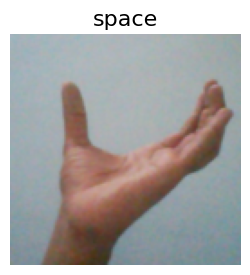

In [12]:
# Plot the image
plt.figure(figsize = (3, 3))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize = 16); 

## 5. Turn loaded images into Dataloaders

In [13]:
# Train and test dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 192
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              num_workers = 1,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)

len(train_dataloader), len(test_dataloader)

(1530, 383)

In [14]:
img, label = next(iter(train_dataloader))

img.shape, label.shape     # {img.shape} -> [batch_size, color_channels, height, width]

(torch.Size([192, 3, 128, 128]), torch.Size([192]))

## 6. Transfer Learning using `EfficientNetB0`

In [15]:
!pip install efficientnet_pytorch torchinfo

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16428 sha256=5581ad63457e4ec2543e3833c4dc7f1247b59503637885199c84a293515bd5dd
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [16]:
from efficientnet_pytorch import EfficientNet
from torchinfo import summary

num_classes = len(class_names)    # Number of classes

# Instantiate the EfficientNet model
model = EfficientNet.from_pretrained('efficientnet-b0').to(device)
model._fc = nn.Linear(model._fc.in_features, num_classes)  

# Wrap the real model with DataParallel to use multiple GPUs
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model, device_ids=[0, 1])

# Move the real model to GPU(s)
model.to(device)

summary(model=model,
        input_size=(192, 3, 128, 128),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 149MB/s] 


Loaded pretrained weights for efficientnet-b0
Let's use 2 GPUs!


Layer (type (var_name))                                           Input Shape          Output Shape         Param #              Trainable
DataParallel (DataParallel)                                       [192, 3, 128, 128]   [192, 29]            --                   True
├─EfficientNet (module)                                           [96, 3, 128, 128]    [96, 29]             4,044,697            True
├─EfficientNet (module)                                           --                   --                   (recursive)          True
│    └─Conv2dStaticSamePadding (_conv_stem)                       [96, 3, 128, 128]    [96, 32, 64, 64]     864                  True
│    └─Conv2dStaticSamePadding (_conv_stem)                       --                   --                   (recursive)          True
│    │    └─ZeroPad2d (static_padding)                            [96, 3, 128, 128]    [96, 3, 129, 129]    --                   --
├─EfficientNet (module)                                    

## 7. Create Train/Test Loop Function

In [17]:
def train_step(model, dataloader, loss_fn, optimizer):
    model.train()
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn):
    model.eval()
    test_loss, test_acc = 0, 0

    # Turn on inference
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [18]:
from tqdm.auto import tqdm

def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs):

  # Create a empty results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss":[],
             "test_acc": []}

  # Loop through training and testing steps for no of epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model = model,
                                       dataloader = train_dataloader,
                                       optimizer = optimizer,
                                       loss_fn = loss_fn)

    test_loss, test_acc = test_step(model = model,
                                     dataloader = test_dataloader,
                                     loss_fn = loss_fn)

    print(f'Epoch: {epoch} | Train loss: {train_loss:.4f} - Train acc: {(train_acc*100):.2f}% -  Test loss: {test_loss:.4f} - Test acc: {(test_acc*100):.2f}%')

    # Update results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

## 8. Train and Evaluate the Model

In [19]:
# Setup loss functions and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr=0.001)

In [20]:
EPOCHS = 5

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model
model_results = train(model = model,
                      train_dataloader = train_dataloader,
                      test_dataloader = test_dataloader,
                      optimizer = optimizer,
                      loss_fn = loss_fn,
                      epochs = EPOCHS)

# End the timer and print duration of training
end_time = timer()
print(f'Total Train Time: {end_time - start_time:.3f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 0.0640 - Train acc: 98.26% -  Test loss: 0.0333 - Test acc: 99.02%
Epoch: 1 | Train loss: 0.0150 - Train acc: 99.55% -  Test loss: 0.0329 - Test acc: 99.05%
Epoch: 2 | Train loss: 0.0127 - Train acc: 99.62% -  Test loss: 0.0189 - Test acc: 99.42%
Epoch: 3 | Train loss: 0.0115 - Train acc: 99.67% -  Test loss: 0.0086 - Test acc: 99.78%
Epoch: 4 | Train loss: 0.0088 - Train acc: 99.75% -  Test loss: 0.0095 - Test acc: 99.76%
Total Train Time: 9667.252 seconds


## 9. Plot loss curves and accuracy curves

In [21]:
# Get the model key results
model_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [22]:
def plot_loss_curves(results):
    """ Plots training curves of a results dictionary """

    # Get results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

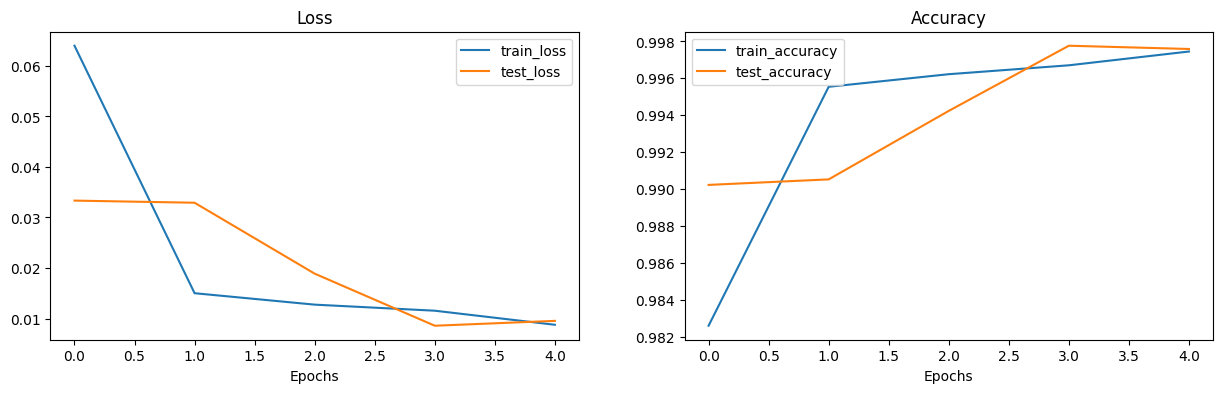

In [23]:
plot_loss_curves(model_results)

## 10. Saving Model

In [24]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# Create model save path
MODEL_NAME = "ASL_HandSignLang_EfficientNetB0_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/ASL_HandSignLang_EfficientNetB0_2.pth


## 12. Making Predictions on Loaded Model

In [28]:
import torch
from torch import nn
from efficientnet_pytorch import EfficientNet

# Path to the saved model state
MODEL_SAVE_PATH = '/kaggle/working/models/ASL_HandSignLang_EfficientNetB0_2.pth'

# Load the pretrained EfficientNet model
loaded_model = EfficientNet.from_pretrained('efficientnet-b0').to('cpu')

# Modify the final fully connected layer to match the number of classes (29 in this case)
loaded_model._fc = nn.Linear(loaded_model._fc.in_features, 29)

# Load the saved state dict into the model
state_dict = torch.load(MODEL_SAVE_PATH, map_location='cpu')

# Strip 'module.' prefix if present
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v

loaded_model.load_state_dict(new_state_dict)

# Move the model to the appropriate device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
loaded_model = loaded_model.to(device)

# Wrap the model with DataParallel to use multiple GPUs
if torch.cuda.device_count() > 1:
    loaded_model = nn.DataParallel(loaded_model, device_ids=[0, 1])

# Print the device of the model parameters to confirm
print(f"Model on device:\n{next(loaded_model.parameters()).device}")


Loaded pretrained weights for efficientnet-b0
Model on device:
cuda:0


In [29]:
def make_predictions(model, data, device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim = 0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)
      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [30]:
import random
# random.seed(42)

test_samples = []
test_labels = []
# test_targets_tensor = torch.tensor(test_data.targets)
for sample, label in random.sample(list(test_data), k = 30):
  test_samples.append(sample)
  test_labels.append(label)

In [31]:
loaded_pred_probs = make_predictions(loaded_model,
                                     test_samples,
                                     device)

loaded_pred_classes = loaded_pred_probs.argmax(dim = 1)

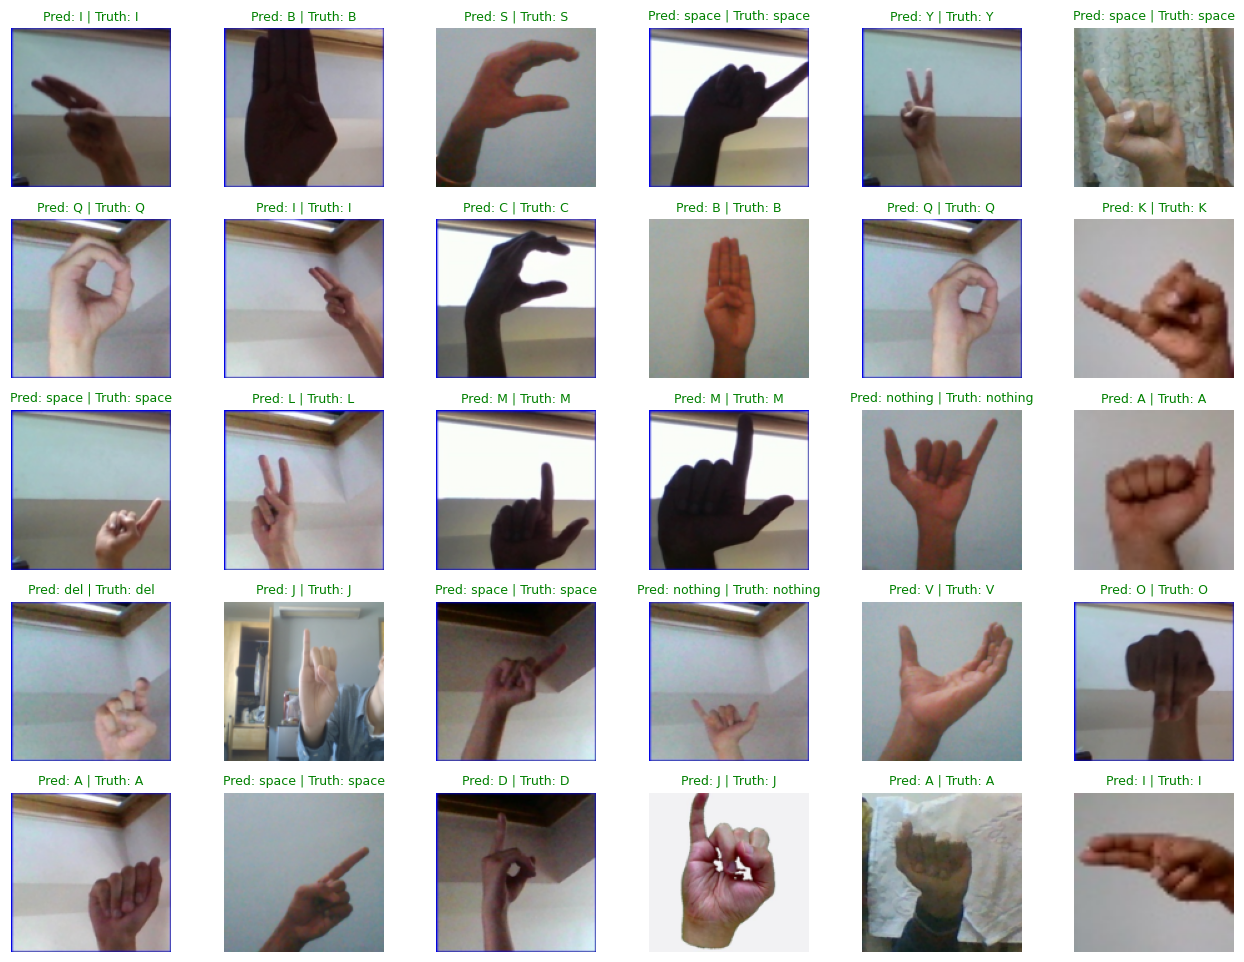

In [32]:
plt.figure(figsize=(16, 12))
nrows, ncols = 5, 6

for i, sample in enumerate(test_samples):
  class_name = np.array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
                      'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
                      'del', 'nothing', 'space'])
  plt.subplot(nrows, ncols, i + 1)
  normalized_sample = sample.permute(1, 2, 0).numpy()
  # normalized_sample = normalized_sample / 255.0
  plt.imshow(normalized_sample)

  pred_label = class_name[loaded_pred_classes[i]]
  truth_label = class_name[test_labels[i]]
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"  
    
  if pred_label == truth_label:
      plt.title(title_text, fontsize=9, c="g")
  else:
      plt.title(title_text, fontsize=9, c="r")

  plt.axis(False);